# 05 — Scenariosimulering og sårbarhetsmål

Stargate +230/+520 MW scenarioer med alle pris-effektmodellene:
**2SLS (HAC)**, **OLS (HAC)**, **QuantReg Q50/Q90**, **OLS (sesong)**, **XGBoost** og **MS-DR**.

ISO-regimeandel (logistisk regresjon) og ekstrempriser.

**Input:** `intermediate/df_processed.parquet`, `intermediate/df_iso.parquet`,
`intermediate/models.pkl`, `intermediate/models_ols_seasonal.pkl`,
`intermediate/models_xgb.pkl`, `intermediate/models_msdr.pkl`,
`intermediate/seasonal_medians.pkl`, `intermediate/cv_folds.pkl`  
**Output:** `intermediate/scenarios.pkl`


In [14]:
import os, warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from src.config import (
    TRAIN_YEARS, TEST_YEARS, INTERMEDIATE_DIR, FIG_DIR,
    TARGET, MODEL_FEATURES, BASE_FEATURES,
    STARGATE_MW, STARGATE_TOTAL_MW,
    SCALE_COLS, SCALED_NAME_MAP, SEASON_DUMMIES, SEASON_ORDER,
    apply_style, C1, C2, C3, C4, C5, PALETTE
)
from src.scenario import build_scenario, fill_group
from src.evaluation import demand_level

apply_style()


In [15]:
df = pd.read_parquet(INTERMEDIATE_DIR + "df_processed.parquet")
df_iso = pd.read_parquet(INTERMEDIATE_DIR + "df_iso.parquet")

# OLS (HAC) — baseline modell (lastes fra 03a-output)
with open(INTERMEDIATE_DIR + "models_ols.pkl", "rb") as f:
    ols_data = pickle.load(f)
ols_model = ols_data["estimator"]

# OLS (sesong) — har ferdig sim_results fra 03a-utvidelse
try:
    with open(INTERMEDIATE_DIR + "models_ols_seasonal.pkl", "rb") as f:
        ols_seasonal_data = pickle.load(f)
    ols_seasonal_model = ols_seasonal_data["models"]
    SEASONAL_FEATURES  = ols_seasonal_data["features"]
    ols_seasonal_sims  = ols_seasonal_data["sim_results"]
    print("OLS (sesong): OK")
except FileNotFoundError:
    print("OBS: models_ols_seasonal.pkl ikke funnet")
    ols_seasonal_sims = {}

# XGBoost — kun estimator, simulering beregnes inline i Seksjon 10
try:
    with open(INTERMEDIATE_DIR + "models_xgb.pkl", "rb") as f:
        xgb_data = pickle.load(f)
    xgb_estimator = xgb_data["estimator"]
    XGB_FEATURES  = xgb_data["feature_cols"]
    print("XGBoost: OK")
except FileNotFoundError:
    print("OBS: models_xgb.pkl ikke funnet")
    xgb_estimator = None

# MS-DR — kun estimator + ergodiske sannsynligheter
try:
    with open(INTERMEDIATE_DIR + "models_msdr.pkl", "rb") as f:
        msdr_data = pickle.load(f)
    msdr_estimator = msdr_data["estimator"]
    print("MS-DR: OK")
except FileNotFoundError:
    print("OBS: models_msdr.pkl ikke funnet")
    msdr_estimator = None

# Sesongmedianer og CV-data
with open(INTERMEDIATE_DIR + "seasonal_medians.pkl", "rb") as f:
    med_data = pickle.load(f)

with open(INTERMEDIATE_DIR + "cv_folds.pkl", "rb") as f:
    cv_data = pickle.load(f)
cv_coef_df = cv_data["cv_coef_df"]

# 2SLS (HAC) — hovedmodell
try:
    with open(INTERMEDIATE_DIR + "models_tsls.pkl", "rb") as f:
        tsls_data = pickle.load(f)
    tsls_estimator = tsls_data["estimator"]
    print("2SLS: OK")
except FileNotFoundError:
    print("OBS: models_tsls.pkl ikke funnet")
    tsls_estimator = None

# Kvantilregresjon — Q50 og Q90
try:
    with open(INTERMEDIATE_DIR + "models_quantreg.pkl", "rb") as f:
        quantreg_data = pickle.load(f)
    quantreg_estimators = quantreg_data["estimators"]   # {0.5: ..., 0.9: ...}
    print("Kvantilregresjon: OK")
except FileNotFoundError:
    print("OBS: models_quantreg.pkl ikke funnet")
    quantreg_estimators = {}

# Etterspørselsterskler
train_cons = df_iso.loc[df_iso.index.year.isin(TRAIN_YEARS), "cons_NO4"]
t1, t2 = train_cons.quantile([1/3, 2/3])

print(f"\ndf: {len(df):,}, df_iso: {len(df_iso):,} ISO-timer")


OLS (sesong): OK
XGBoost: OK
MS-DR: OK
2SLS: OK
Kvantilregresjon: OK

df: 53,394, df_iso: 34,916 ISO-timer


---
## Seksjon 10 — Scenariosimulering


In [16]:
SEC10_DIR = FIG_DIR + "05/"
os.makedirs(SEC10_DIR, exist_ok=True)

# OLS (HAC): beregn ΔP direkte (lineær → konstant effekt per time)
X_base   = df_iso[MODEL_FEATURES]
X_base_c = sm.add_constant(X_base)

# MS-DR: ergodisk-vektet β for cons_NO4 → konstant ΔP per time
_msdr_b0 = msdr_estimator.params["x1[0]"]
_msdr_b1 = msdr_estimator.params["x1[1]"]
_pi0, _pi1 = msdr_data["ergodic_probs"]
_msdr_beta_w = _pi0 * _msdr_b0 + _pi1 * _msdr_b1

MODEL_DP = {
    "2SLS (HAC)":   "dP_TSLS",
    "OLS (HAC)":    "dP_OLS",
    "QuantReg Q50": "dP_Q50",
    "QuantReg Q90": "dP_Q90",
    "OLS (sesong)": "dP_OLS_seasonal",
    "XGBoost":      "dP_XGB",
    "MS-DR":        "dP_MSDR",
}

scenarios = {}
for delta, label in [(STARGATE_MW, f"Fase 1 (+{STARGATE_MW} MW)"),
                     (STARGATE_TOTAL_MW, f"Fase 1+2 (+{STARGATE_TOTAL_MW} MW)")]:
    X_scen   = build_scenario(X_base, delta)
    X_scen_c = sm.add_constant(X_scen)

    # Lineære modeller — konstant marginaleffekt innenfor ISO-timer
    dP_tsls = pd.Series(tsls_estimator.params["cons_NO4"] * delta, index=df_iso.index)
    dP_ols = ols_model.predict(X_scen_c) - ols_model.predict(X_base_c)
    dP_q50 = pd.Series(quantreg_estimators[0.5].params["cons_NO4"] * delta, index=df_iso.index)
    dP_q90 = pd.Series(quantreg_estimators[0.9].params["cons_NO4"] * delta, index=df_iso.index)

    # XGBoost — ikke-lineær, må prediktes på base og scenario
    X_base_xgb = df_iso[XGB_FEATURES]
    X_scen_xgb = build_scenario(X_base_xgb, delta)
    dP_xgb = xgb_estimator.predict(X_scen_xgb) - xgb_estimator.predict(X_base_xgb)

    # MS-DR — lineær per regime, ergodisk-vektet β gir konstant ΔP
    dP_msdr = pd.Series(_msdr_beta_w * delta, index=df_iso.index)

    result = pd.DataFrame(index=df_iso.index)
    result["season"]       = df_iso["season"].values
    result["cons_NO4"]     = df_iso["cons_NO4"].values
    result["demand_level"] = df_iso["cons_NO4"].map(lambda c: demand_level(c, t1, t2))

    result["dP_TSLS"]         = dP_tsls.values
    result["dP_OLS"]          = dP_ols
    result["dP_Q50"]          = dP_q50.values
    result["dP_Q90"]          = dP_q90.values
    result["dP_OLS_seasonal"] = ols_seasonal_sims[delta]["dP"].values
    result["dP_XGB"]          = dP_xgb
    result["dP_MSDR"]         = dP_msdr.values

    for col in MODEL_DP.values():
        result[f"P_scen_{col}"] = df_iso[TARGET].values + result[col].values

    scenarios[delta] = result
    print(f"{label}:")
    for name, col in MODEL_DP.items():
        print(f"  {name:24s} snitt ΔP = {result[col].mean():+.1f} NOK/MWh")

print("\nScenarier beregnet.")


Fase 1 (+230 MW):
  2SLS (HAC)               snitt ΔP = +147.5 NOK/MWh
  OLS (HAC)                snitt ΔP = +69.8 NOK/MWh
  QuantReg Q50             snitt ΔP = +25.6 NOK/MWh
  QuantReg Q90             snitt ΔP = +50.9 NOK/MWh
  OLS (sesong)             snitt ΔP = +58.0 NOK/MWh
  XGBoost                  snitt ΔP = +64.4 NOK/MWh
  MS-DR                    snitt ΔP = +62.6 NOK/MWh
Fase 1+2 (+520 MW):
  2SLS (HAC)               snitt ΔP = +333.6 NOK/MWh
  OLS (HAC)                snitt ΔP = +157.8 NOK/MWh
  QuantReg Q50             snitt ΔP = +57.8 NOK/MWh
  QuantReg Q90             snitt ΔP = +115.1 NOK/MWh
  OLS (sesong)             snitt ΔP = +131.1 NOK/MWh
  XGBoost                  snitt ΔP = +137.2 NOK/MWh
  MS-DR                    snitt ΔP = +141.6 NOK/MWh

Scenarier beregnet.


In [17]:
# Tabell 1: ΔP totalt og per sesong
for delta, label in [(STARGATE_MW, f"Fase 1 (+{STARGATE_MW} MW)"),
                     (STARGATE_TOTAL_MW, f"Fase 1+2 (+{STARGATE_TOTAL_MW} MW)")]:
    res = scenarios[delta]
    print("=" * 70)
    print(f"ΔP (NOK/MWh) — {label}")
    print("=" * 70)

    rows = []
    for name, col in MODEL_DP.items():
        row = {"Modell": name, "Total": round(res[col].mean(), 1)}
        for s_en, s_no in SEASON_ORDER.items():
            mask = res["season"] == s_en
            row[s_no] = round(res.loc[mask, col].mean(), 1)
        rows.append(row)

    display(pd.DataFrame(rows).set_index("Modell").style.format("{:.1f}"))
    print()


ΔP (NOK/MWh) — Fase 1 (+230 MW)


,Total,Vinter,Vår,Sommer,Høst
Modell,,,,,
2SLS (HAC),147.5,147.5,147.5,147.5,147.5
OLS (HAC),69.8,69.8,69.8,69.8,69.8
QuantReg Q50,25.6,25.6,25.6,25.6,25.6
QuantReg Q90,50.9,50.9,50.9,50.9,50.9
OLS (sesong),58.0,158.7,61.5,-37.5,39.0
XGBoost,64.4,121.1,56.2,3.5,71.5
MS-DR,62.6,62.6,62.6,62.6,62.6



ΔP (NOK/MWh) — Fase 1+2 (+520 MW)


,Total,Vinter,Vår,Sommer,Høst
Modell,,,,,
2SLS (HAC),333.6,333.6,333.6,333.6,333.6
OLS (HAC),157.8,157.8,157.8,157.8,157.8
QuantReg Q50,57.8,57.8,57.8,57.8,57.8
QuantReg Q90,115.1,115.1,115.1,115.1,115.1
OLS (sesong),131.1,358.8,139.0,-84.9,88.2
XGBoost,137.2,196.5,153.5,29.6,166.1
MS-DR,141.6,141.6,141.6,141.6,141.6


In [18]:
# Tabell 2: ΔP per etterspørselsnivå
for delta, label in [(STARGATE_MW, f"+{STARGATE_MW} MW"),
                     (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
    res = scenarios[delta]
    print(f"ΔP per etterspørselsnivå — {label}")
    rows = []
    for level in ["Lav", "Normal", "Høy"]:
        mask = res["demand_level"] == level
        row = {"Etterspørsel": level}
        for name, col in MODEL_DP.items():
            row[name] = round(res.loc[mask, col].mean(), 1)
        rows.append(row)
    display(pd.DataFrame(rows).set_index("Etterspørsel").style.format("{:.1f}"))
    print()


ΔP per etterspørselsnivå — +230 MW


,2SLS (HAC),OLS (HAC),QuantReg Q50,QuantReg Q90,OLS (sesong),XGBoost,MS-DR
Etterspørsel,,,,,,,
Lav,147.5,69.8,25.6,50.9,-11.1,4.1,62.6
Normal,147.5,69.8,25.6,50.9,52.3,51.6,62.6
Høy,147.5,69.8,25.6,50.9,118.3,124.0,62.6



ΔP per etterspørselsnivå — +520 MW


,2SLS (HAC),OLS (HAC),QuantReg Q50,QuantReg Q90,OLS (sesong),XGBoost,MS-DR
Etterspørsel,,,,,,,
Lav,333.6,157.8,57.8,115.1,-25.0,19.1,141.6
Normal,333.6,157.8,57.8,115.1,118.2,210.7,141.6
Høy,333.6,157.8,57.8,115.1,267.6,169.3,141.6


In [19]:
beta_cons = ols_model.params["cons_NO4"]
se_cons   = ols_model.bse["cons_NO4"]
cv_beta_min = cv_coef_df["cons_NO4"].min()
cv_beta_max = cv_coef_df["cons_NO4"].max()

print("=" * 70)
print("ΔP-INTERVALL (OLS HAC)")
print("=" * 70)
for delta, label in [(STARGATE_MW, f"+{STARGATE_MW} MW"),
                     (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
    dp    = beta_cons * delta
    ci_lo = (beta_cons - 1.96 * se_cons) * delta
    ci_hi = (beta_cons + 1.96 * se_cons) * delta
    cv_lo = cv_beta_min * delta
    cv_hi = cv_beta_max * delta
    print(f"\n  {label}:")
    print(f"    OLS: ΔP = {dp:+.1f} NOK/MWh  95% KI [{ci_lo:+.1f}, {ci_hi:+.1f}]")
    print(f"    CV-intervall: [{cv_lo:+.1f}, {cv_hi:+.1f}] NOK/MWh")

print(f"\n{'=' * 70}")
print("MODELLSPENN (snitt ΔP over alle modellene)")
print("=" * 70)
for delta, label in [(STARGATE_MW, f"+{STARGATE_MW} MW"),
                     (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
    res = scenarios[delta]
    dp_means = {name: res[col].mean() for name, col in MODEL_DP.items()}
    print(f"\n  {label}: [{min(dp_means.values()):+.1f}, {max(dp_means.values()):+.1f}] NOK/MWh")


ΔP-INTERVALL (OLS HAC)

  +230 MW:
    OLS: ΔP = +69.8 NOK/MWh  95% KI [+53.5, +86.1]
    CV-intervall: [-5.6, +74.1] NOK/MWh

  +520 MW:
    OLS: ΔP = +157.8 NOK/MWh  95% KI [+121.0, +194.6]
    CV-intervall: [-12.6, +167.5] NOK/MWh

MODELLSPENN (snitt ΔP over alle modellene)

  +230 MW: [+25.6, +147.5] NOK/MWh

  +520 MW: [+57.8, +333.6] NOK/MWh


---
## Seksjon 11 — Sårbarhetsmål


In [20]:
# Mål 1: ISO-regimeandel (logistisk regresjon)
# Bruker StandardScaler-tilnærmingen (ikke sesongjustert)
SEC11_DIR = FIG_DIR + "05/"
os.makedirs(SEC11_DIR, exist_ok=True)

df["is_iso"] = (df["regime_group"] == "ISO").astype(int)

# Fit scaler for logit
scaler = StandardScaler()
scaler.fit(df.loc[df.index.year.isin(TRAIN_YEARS), SCALE_COLS])
scaled = scaler.transform(df[SCALE_COLS])
for i, col in enumerate(SCALE_COLS):
    df[SCALED_NAME_MAP[col]] = scaled[:, i]

for s in SEASON_DUMMIES:
    df[s] = (df["season"] == s).astype(int)

LOGIT_FEATURES = ["cons_c", "fill_c"] + SEASON_DUMMIES
df_logit_train = df[df.index.year.isin(TRAIN_YEARS)]

logit_model = LogisticRegression(max_iter=1000, random_state=42)
logit_model.fit(df_logit_train[LOGIT_FEATURES], df_logit_train["is_iso"])

baseline_iso_share = df["is_iso"].mean()
print(f"Faktisk ISO-andel: {baseline_iso_share*100:.1f}%")

iso_share_results = []
for delta, label in [(0, "Baseline"), (STARGATE_MW, f"+{STARGATE_MW} MW"),
                     (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
    df_scen = df.copy()
    if delta > 0:
        df_scen["cons_NO4"] = df_scen["cons_NO4"] + delta
        if "net_position" in df_scen.columns:
            df_scen["net_position"] = df_scen["prod_total_NO4"] - df_scen["cons_NO4"]
        scaled_scen = scaler.transform(df_scen[SCALE_COLS])
        for i, col in enumerate(SCALE_COLS):
            df_scen[SCALED_NAME_MAP[col]] = scaled_scen[:, i]

    p_iso = logit_model.predict_proba(df_scen[LOGIT_FEATURES])[:, 1]
    row = {"Scenario": label, "Total": round(p_iso.mean() * 100, 1)}
    for s_en, s_no in SEASON_ORDER.items():
        mask = df_scen["season"] == s_en
        row[s_no] = round(p_iso[mask].mean() * 100, 1)
    iso_share_results.append(row)

iso_share_df = pd.DataFrame(iso_share_results).set_index("Scenario")
print("\nPredikert ISO-andel (%):")
display(iso_share_df.style.format("{:.1f}"))


Faktisk ISO-andel: 65.4%

Predikert ISO-andel (%):


,Total,Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,72.5,76.0,67.6,75.5,70.8
+230 MW,76.0,79.1,71.4,78.7,74.7
+520 MW,80.0,82.7,75.9,82.4,79.0


In [21]:
# Mål 2: Ekstrempriser (P > 90. persentil)
p90_threshold = np.percentile(df_iso[TARGET], 90)
fill_median = df_iso["fill_rate"].median()

print(f"P90-terskel: {p90_threshold:.1f} NOK/MWh")

# Beregn for hver modell
for model_name, dp_col in MODEL_DP.items():
    print(f"\n{'=' * 70}")
    print(f"Andel timer med pris > P90 — {model_name}")
    print("=" * 70)

    extreme_rows = []
    for delta, label in [(0, "Baseline"), (STARGATE_MW, f"+{STARGATE_MW} MW"),
                         (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
        if delta == 0:
            prices = df_iso[TARGET]
        else:
            prices = scenarios[delta][f"P_scen_{dp_col}"]

        pct = 100 * (prices > p90_threshold).sum() / len(prices)
        row = {"Scenario": label, "Total (%)": round(pct, 1)}

        for s_en, s_no in SEASON_ORDER.items():
            mask = df_iso["season"] == s_en
            p_sub = prices[mask] if delta == 0 else prices.iloc[mask.values]
            row[s_no] = round(100 * (p_sub > p90_threshold).sum() / len(p_sub), 1) if len(p_sub) > 0 else 0

        extreme_rows.append(row)

    display(pd.DataFrame(extreme_rows).set_index("Scenario"))


P90-terskel: 543.5 NOK/MWh

Andel timer med pris > P90 — 2SLS (HAC)


,Total (%),Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,10.0,19.6,8.4,1.4,9.5
+230 MW,21.8,39.6,20.0,5.5,20.3
+520 MW,49.3,66.2,50.4,40.9,37.6



Andel timer med pris > P90 — OLS (HAC)


,Total (%),Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,10.0,19.6,8.4,1.4,9.5
+230 MW,15.4,28.3,12.7,3.1,16.0
+520 MW,22.8,41.1,21.4,6.0,20.7



Andel timer med pris > P90 — QuantReg Q50


...

,Total (%),Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,10.0,19.6,8.4,1.4,9.5
+230 MW,17.4,41.2,12.2,0.8,12.7
+520 MW,27.8,70.2,18.7,0.4,17.0



Andel timer med pris > P90 — XGBoost


,Total (%),Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,10.0,19.6,8.4,1.4,9.5
+230 MW,15.6,33.3,13.2,1.4,12.7
+520 MW,23.8,43.2,24.7,1.8,23.6



Andel timer med pris > P90 — MS-DR


,Total (%),Vinter,Vår,Sommer,Høst
Scenario,,,,,
Baseline,10.0,19.6,8.4,1.4,9.5
+230 MW,14.8,27.3,12.3,2.9,15.4
+520 MW,20.9,37.9,18.9,5.2,19.7


---
## Seksjon 12 — MS-DR: Regime-spesifikke forbrukskoeffisienter

β̂_Q per regime med 95 % KI, steady-state sannsynligheter og vektet ΔP.


MS-DR: Regime-spesifikke forbrukskoeffisienter
Regime 0 (lav volatilitet): β = 0.14698  KI [0.14364, 0.15033]
  → ΔP (+230 MW) = 33.8  KI [33.0, 34.6] NOK/MWh
Regime 1 (høy volatilitet): β = 0.39753  KI [0.38291, 0.41216]
  → ΔP (+230 MW) = 91.4  KI [88.1, 94.8] NOK/MWh

Steady-state: π₀ = 0.500, π₁ = 0.500
Vektet ΔP = 62.6 NOK/MWh  KI [60.6, 64.7]
(Kontroll mot scenarios-snitt: 62.6 NOK/MWh)


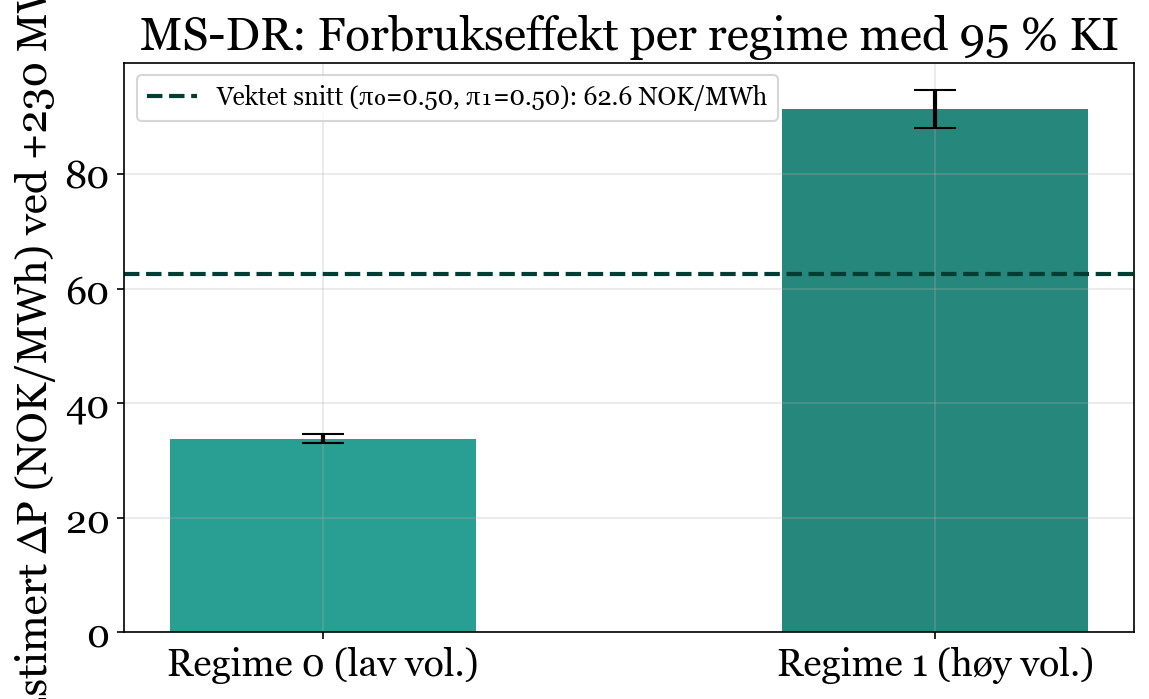

In [22]:
import os
SEC12_DIR = f"{FIG_DIR}05/"
os.makedirs(SEC12_DIR, exist_ok=True)

msdr_result = msdr_data["estimator"]

# Regime-spesifikke β̂_Q (x1 = cons_NO4, x2 = fill_avvik, x3 = prod_wind_NO4)
_b0   = msdr_result.params["x1[0]"]
_b1   = msdr_result.params["x1[1]"]
_ci   = msdr_result.conf_int(alpha=0.05)
_ci0  = (_ci.loc["x1[0]", 0], _ci.loc["x1[0]", 1])
_ci1  = (_ci.loc["x1[1]", 0], _ci.loc["x1[1]", 1])

# Steady-state direkte fra lagrede ergodiske sannsynligheter
_pi0, _pi1 = msdr_data["ergodic_probs"]

_dP0 = _b0 * STARGATE_MW
_dP1 = _b1 * STARGATE_MW
_dP_w = (_pi0 * _b0 + _pi1 * _b1) * STARGATE_MW

# 95 % KI for vektet ΔP (pi fast, usikkerhet fra koeffisient-KI)
_dP_w_lo = (_pi0 * _ci0[0] + _pi1 * _ci1[0]) * STARGATE_MW
_dP_w_hi = (_pi0 * _ci0[1] + _pi1 * _ci1[1]) * STARGATE_MW

print("MS-DR: Regime-spesifikke forbrukskoeffisienter")
print("=" * 65)
print(f"Regime 0 (lav volatilitet): β = {_b0:.5f}  "
      f"KI [{_ci0[0]:.5f}, {_ci0[1]:.5f}]")
print(f"  → ΔP (+{STARGATE_MW} MW) = {_dP0:.1f}  "
      f"KI [{_ci0[0]*STARGATE_MW:.1f}, {_ci0[1]*STARGATE_MW:.1f}] NOK/MWh")
print(f"Regime 1 (høy volatilitet): β = {_b1:.5f}  "
      f"KI [{_ci1[0]:.5f}, {_ci1[1]:.5f}]")
print(f"  → ΔP (+{STARGATE_MW} MW) = {_dP1:.1f}  "
      f"KI [{_ci1[0]*STARGATE_MW:.1f}, {_ci1[1]*STARGATE_MW:.1f}] NOK/MWh")
print(f"\nSteady-state: π₀ = {_pi0:.3f}, π₁ = {_pi1:.3f}")
print(f"Vektet ΔP = {_dP_w:.1f} NOK/MWh  "
      f"KI [{_dP_w_lo:.1f}, {_dP_w_hi:.1f}]")
print(f"(Kontroll mot scenarios-snitt: "
      f"{scenarios[STARGATE_MW]['dP_MSDR'].mean():.1f} NOK/MWh)")

fig, ax = plt.subplots(figsize=(8, 5))
_regs   = ["Regime 0 (lav vol.)", "Regime 1 (høy vol.)"]
_betas  = [_b0, _b1]
_cis    = [_ci0, _ci1]
_rcols  = [C1, C2]

for i, (reg, b, ci, col) in enumerate(zip(_regs, _betas, _cis, _rcols)):
    ax.bar(i, b * STARGATE_MW, color=col, alpha=0.85, width=0.5)
    ax.errorbar(
        i, b * STARGATE_MW,
        yerr=[[(b - ci[0]) * STARGATE_MW], [(ci[1] - b) * STARGATE_MW]],
        fmt="none", color="black", capsize=10, lw=2
    )

ax.axhline(_dP_w, color=C4, ls="--", lw=2,
           label=f"Vektet snitt (π₀={_pi0:.2f}, π₁={_pi1:.2f}): {_dP_w:.1f} NOK/MWh")
ax.set_xticks([0, 1])
ax.set_xticklabels(_regs)
ax.set_ylabel("Estimert ΔP (NOK/MWh) ved +230 MW")
ax.set_title("MS-DR: Forbrukseffekt per regime med 95 % KI")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{SEC12_DIR}msdr_koeff_per_regime.pdf", bbox_inches="tight")
plt.show()


---
## Seksjon 13 — Total priseffekt (dekomponert)

ΔE[P] ≈ Pr(I=1)·ΔE[P|I=1] + ΔPr(I=1)·ΔP_gap

- **Term 1** (direkte effekt i ISO-timer): eksisterende ISO-andel × ΔP fra scenariosimulering
- **Term 2** (regimeskift): økning i ISO-andel × historisk prisgap (ISO minus ikke-ISO)
- **Term 3** (direkte effekt utenfor ISO) ≈ 0 (pristaker-antagelse)

ΔP_gap hentes fra historiske råpriser i df_processed.
ISO-andel og ΔPr(ISO) fra logistisk regresjon (Seksjon 11).
ΔE[P|I=1] fra scenariosimulering per modell (Seksjon 10).


ΔP_gap totalt: 75.4 NOK/MWh
  Vinter  : 81.3
  Vår     : 63.2
  Sommer  : 54.3
  Høst    : 78.9
  Lav     : 80.8
  Normal  : 71.6
  Høy     : 32.3

=== Total priseffekt — dekomponert ===


,Scenario,Modell,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO (NOK/MWh),ΔP_gap (NOK/MWh),Term 1 — direkte,Term 2 — regimeskift,Total ΔE[P] (NOK/MWh)
0,+230 MW,2SLS (HAC),72.5,3.5,147.500000,75.4,107.0,2.6,109.6
1,+230 MW,OLS (HAC),72.5,3.5,69.800000,75.4,50.6,2.6,53.2
2,+230 MW,QuantReg Q50,72.5,3.5,25.600000,75.4,18.5,2.6,21.2
3,+230 MW,QuantReg Q90,72.5,3.5,50.900000,75.4,36.9,2.6,39.5
4,+230 MW,OLS (sesong),72.5,3.5,58.000000,75.4,42.0,2.6,44.7
5,+230 MW,XGBoost,72.5,3.5,64.400002,75.4,46.7,2.6,49.4
6,+230 MW,MS-DR,72.5,3.5,62.600000,75.4,45.4,2.6,48.0
7,+520 MW,2SLS (HAC),72.5,7.5,333.600000,75.4,241.8,5.7,247.5
8,+520 MW,OLS (HAC),72.5,7.5,157.800000,75.4,114.4,5.7,120.0
9,+520 MW,QuantReg Q50,72.5,7.5,57.800000,75.4,41.9,5.7,47.6



=== Per sesong (OLS HAC) ===


,Scenario,Sesong,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO,ΔP_gap,Term 1,Term 2,Total ΔE[P]
0,+230 MW,Vinter,76.0,3.1,69.8,81.3,53.0,2.5,55.6
1,+230 MW,Vår,67.6,3.8,69.8,63.2,47.2,2.4,49.6
2,+230 MW,Sommer,75.5,3.2,69.8,54.3,52.7,1.7,54.4
3,+230 MW,Høst,70.8,3.9,69.8,78.9,49.4,3.1,52.5
4,+520 MW,Vinter,76.0,6.7,157.8,81.3,119.9,5.4,125.4
5,+520 MW,Vår,67.6,8.3,157.8,63.2,106.7,5.2,111.9
6,+520 MW,Sommer,75.5,6.9,157.8,54.3,119.1,3.7,122.9
7,+520 MW,Høst,70.8,8.2,157.8,78.9,111.7,6.5,118.2



=== Per etterspørselsnivå (OLS HAC) ===


,Scenario,Etterspørsel,Pr(ISO) (%),ΔPr(ISO) (pp),ΔP|ISO,ΔP_gap,Term 1,Term 2,Total ΔE[P]
0,+230 MW,Lav,71.1,3.58,69.8,80.8,49.6,2.9,52.5
1,+230 MW,Normal,69.8,3.78,69.8,71.6,48.7,2.7,51.4
2,+230 MW,Høy,76.4,3.20,69.8,32.3,53.3,1.0,54.3
3,+520 MW,Lav,71.1,7.69,157.8,80.8,112.2,6.2,118.4
4,+520 MW,Normal,69.8,8.11,157.8,71.6,110.1,5.8,115.9
5,+520 MW,Høy,76.4,6.80,157.8,32.3,120.5,2.2,122.7


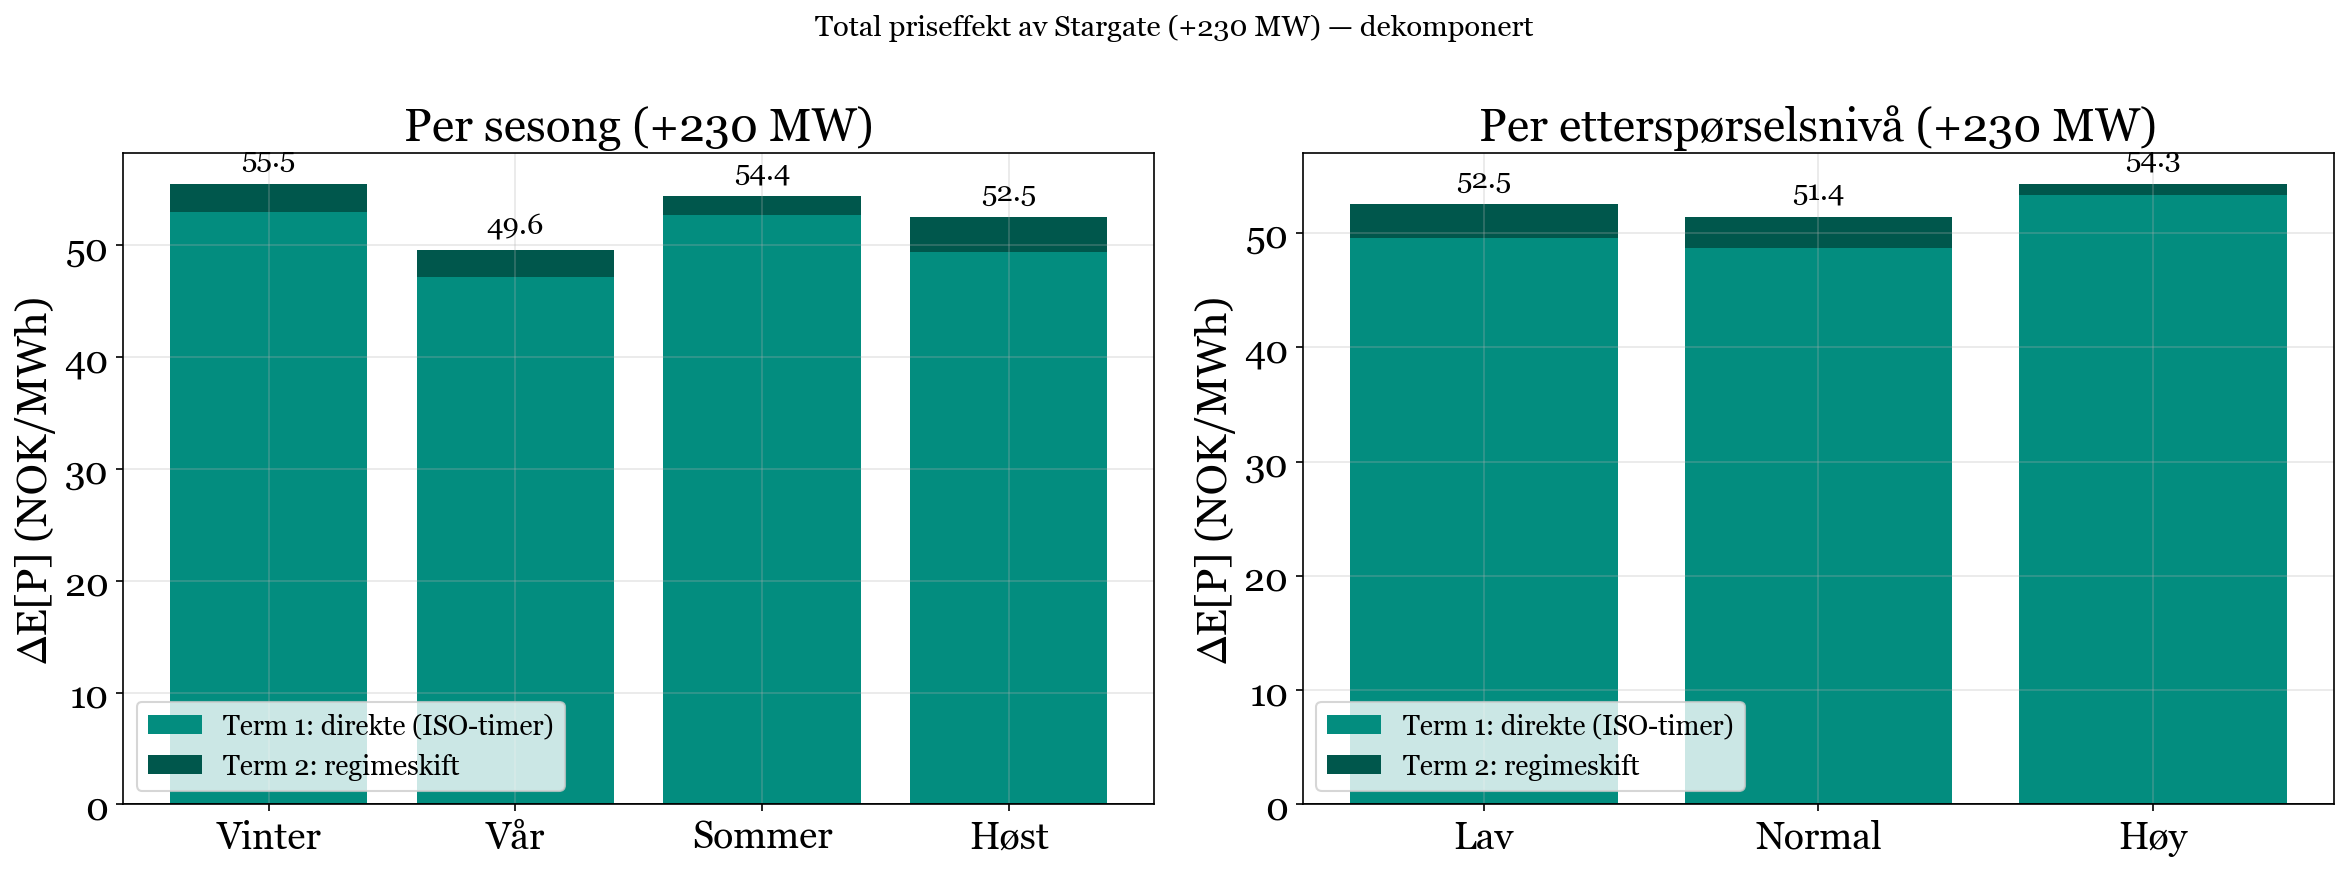

In [23]:
SEC13_DIR = f"{FIG_DIR}05/"
os.makedirs(SEC13_DIR, exist_ok=True)

# ── 1. ΔP_gap: historisk prisgap ISO vs. ikke-ISO ─────────────────────────────
# df["is_iso"] allerede satt i Seksjon 11
p_iso_mean    = df.loc[df["is_iso"] == 1, "price_NO4"].mean()
p_noniso_mean = df.loc[df["is_iso"] == 0, "price_NO4"].mean()
dp_gap_total  = p_iso_mean - p_noniso_mean

dp_gap_season = {}
for s_en in SEASON_ORDER:
    m = df["season"] == s_en
    dp_gap_season[s_en] = (df.loc[m & (df["is_iso"]==1), "price_NO4"].mean()
                          - df.loc[m & (df["is_iso"]==0), "price_NO4"].mean())

# Per etterspørselsnivå
df["demand_level_all"] = df["cons_NO4"].map(lambda c: demand_level(c, t1, t2))
dp_gap_demand = {}
for dl in ["Lav", "Normal", "Høy"]:
    m = df["demand_level_all"] == dl
    dp_gap_demand[dl] = (df.loc[m & (df["is_iso"]==1), "price_NO4"].mean()
                        - df.loc[m & (df["is_iso"]==0), "price_NO4"].mean())

print(f"ΔP_gap totalt: {dp_gap_total:.1f} NOK/MWh")
for s_en, gap in dp_gap_season.items():
    print(f"  {SEASON_ORDER[s_en]:8s}: {gap:.1f}")
for dl, gap in dp_gap_demand.items():
    print(f"  {dl:8s}: {gap:.1f}")

# ── 2. ΔPr(ISO) per etterspørselsnivå (kjøres fra logit-modellen) ─────────────
iso_demand_rows = {}
for delta_val, lbl in [(0, "Baseline"),
                       (STARGATE_MW,       f"+{STARGATE_MW} MW"),
                       (STARGATE_TOTAL_MW, f"+{STARGATE_TOTAL_MW} MW")]:
    df_s = df.copy()
    if delta_val > 0:
        df_s["cons_NO4"] += delta_val
        if "net_position" in df_s.columns:
            df_s["net_position"] = df_s["prod_total_NO4"] - df_s["cons_NO4"]
        sc = scaler.transform(df_s[SCALE_COLS])
        for _i, col in enumerate(SCALE_COLS):
            df_s[SCALED_NAME_MAP[col]] = sc[:, _i]
    p_hat = logit_model.predict_proba(df_s[LOGIT_FEATURES])[:, 1]
    iso_demand_rows[lbl] = {}
    for dl in ["Lav", "Normal", "Høy"]:
        m = df["demand_level_all"] == dl
        iso_demand_rows[lbl][dl] = p_hat[m.values].mean()

# ── 3. Totaleffekt-tabell — alle modeller, begge scenarier ───────────────────
SCEN_LABEL_MAP = {
    STARGATE_MW:       f"+{STARGATE_MW} MW",
    STARGATE_TOTAL_MW: f"+{STARGATE_TOTAL_MW} MW",
}

total_rows = []
for delta in [STARGATE_MW, STARGATE_TOTAL_MW]:
    iso_lbl = SCEN_LABEL_MAP[delta]
    res     = scenarios[delta]
    pr_base  = iso_share_df.loc["Baseline", "Total"] / 100
    pr_scen  = iso_share_df.loc[iso_lbl,    "Total"] / 100
    d_pr     = pr_scen - pr_base

    for model_name, dp_col in MODEL_DP.items():
        dP_iso = res[dp_col].mean()
        t1_val = pr_base * dP_iso
        t2_val = d_pr    * dp_gap_total
        total_rows.append({
            "Scenario":              iso_lbl,
            "Modell":                model_name,
            "Pr(ISO) (%)":           round(pr_base * 100, 1),
            "ΔPr(ISO) (pp)":         round(d_pr    * 100, 2),
            "ΔP|ISO (NOK/MWh)":      round(dP_iso,         1),
            "ΔP_gap (NOK/MWh)":      round(dp_gap_total,   1),
            "Term 1 — direkte":      round(t1_val,          1),
            "Term 2 — regimeskift":  round(t2_val,          1),
            "Total ΔE[P] (NOK/MWh)": round(t1_val + t2_val, 1),
        })

df_total = pd.DataFrame(total_rows)
print("\n=== Total priseffekt — dekomponert ===")
display(df_total)

# ── 4. Stratifisert per sesong — OLS (HAC) ────────────────────────────────────
season_rows = []
for delta in [STARGATE_MW, STARGATE_TOTAL_MW]:
    iso_lbl = SCEN_LABEL_MAP[delta]
    res     = scenarios[delta]
    for s_en, s_no in SEASON_ORDER.items():
        pr_base_s = iso_share_df.loc["Baseline", s_no] / 100
        pr_scen_s = iso_share_df.loc[iso_lbl,    s_no] / 100
        d_pr_s    = pr_scen_s - pr_base_s
        gap_s     = dp_gap_season[s_en]
        mask_s    = res["season"] == s_en
        dP_iso_s  = res.loc[mask_s, "dP_OLS"].mean()
        t1_s = pr_base_s * dP_iso_s
        t2_s = d_pr_s    * gap_s
        season_rows.append({
            "Scenario": iso_lbl, "Sesong": s_no,
            "Pr(ISO) (%)": round(pr_base_s * 100, 1),
            "ΔPr(ISO) (pp)": round(d_pr_s * 100, 2),
            "ΔP|ISO": round(dP_iso_s, 1), "ΔP_gap": round(gap_s, 1),
            "Term 1": round(t1_s, 1), "Term 2": round(t2_s, 1),
            "Total ΔE[P]": round(t1_s + t2_s, 1),
        })

df_season_total = pd.DataFrame(season_rows)
print("\n=== Per sesong (OLS HAC) ===")
display(df_season_total)

# ── 5. Stratifisert per etterspørselsnivå — OLS (HAC) ─────────────────────────
demand_rows_total = []
for delta in [STARGATE_MW, STARGATE_TOTAL_MW]:
    iso_lbl = SCEN_LABEL_MAP[delta]
    res     = scenarios[delta]
    for dl in ["Lav", "Normal", "Høy"]:
        pr_base_d = iso_demand_rows["Baseline"][dl]
        pr_scen_d = iso_demand_rows[iso_lbl][dl]
        d_pr_d    = pr_scen_d - pr_base_d
        gap_d     = dp_gap_demand[dl]
        mask_d    = res["demand_level"] == dl
        dP_iso_d  = res.loc[mask_d, "dP_OLS"].mean()
        t1_d = pr_base_d * dP_iso_d
        t2_d = d_pr_d    * gap_d
        demand_rows_total.append({
            "Scenario": iso_lbl, "Etterspørsel": dl,
            "Pr(ISO) (%)": round(pr_base_d * 100, 1),
            "ΔPr(ISO) (pp)": round(d_pr_d * 100, 2),
            "ΔP|ISO": round(dP_iso_d, 1), "ΔP_gap": round(gap_d, 1),
            "Term 1": round(t1_d, 1), "Term 2": round(t2_d, 1),
            "Total ΔE[P]": round(t1_d + t2_d, 1),
        })

df_demand_total = pd.DataFrame(demand_rows_total)
print("\n=== Per etterspørselsnivå (OLS HAC) ===")
display(df_demand_total)

# ── 6. Plott — stacked bar per sesong og etterspørsel (+230 MW) ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (df_strat, strat_col, title) in zip(axes, [
    (df_season_total[df_season_total["Scenario"] == f"+{STARGATE_MW} MW"],
     "Sesong", f"Per sesong (+{STARGATE_MW} MW)"),
    (df_demand_total[df_demand_total["Scenario"] == f"+{STARGATE_MW} MW"],
     "Etterspørsel", f"Per etterspørselsnivå (+{STARGATE_MW} MW)"),
]):
    cats   = df_strat[strat_col].tolist()
    t1_v   = df_strat["Term 1"].values
    t2_v   = df_strat["Term 2"].values
    x      = np.arange(len(cats))

    ax.bar(x, t1_v, color=C1, label="Term 1: direkte (ISO-timer)")
    ax.bar(x, t2_v, bottom=t1_v, color=C3, label="Term 2: regimeskift")
    total_v = t1_v + t2_v
    for xi, tv in zip(x, total_v):
        ax.text(xi, tv + 1, f"{tv:.1f}", ha="center", va="bottom", fontsize=14)

    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel("ΔE[P] (NOK/MWh)")
    ax.set_title(title)
    ax.legend(fontsize=13)

fig.suptitle(f"Total priseffekt av Stargate (+{STARGATE_MW} MW) — dekomponert", fontsize=14)
plt.tight_layout()
plt.savefig(f"{SEC13_DIR}total_priseffekt_dekomponert.pdf", bbox_inches="tight")
plt.show()


---
## Seksjon 14 — Konvergenstabell (alle modeller)

Sammenstilling av estimert priseffekt (+230 MW) på tvers av alle modellene
med tilhørende usikkerhetsmål. Konvergens mellom modellene er sterk evidens
for robusthet.


Konvergenstabell — Estimert priseffekt av +230 MW Stargate-lastøkning


,ΔP (NOK/MWh),KI / spenn,Usikkerhetstype
Modell,,,
2SLS (HAC),147.500000,"[110.0, 185.1]",95 % HAC KI
OLS (HAC),69.800000,"[53.5, 86.1]",95 % HAC KI
OLS (sesong),58.000000,Vinter: 159 — Sommer: -38,Sesongspenn
XGBoost,64.400002,Vinter: 121 — Sommer: 3,Sesongspenn
MS-DR (vektet),62.600000,"[60.6, 64.7]",Regime-vektet 95 % KI
QuantReg Q50,25.600000,"[23.4, 27.8]",95 % KI
QuantReg Q90,50.900000,"[46.9, 55.0]",95 % KI



Lagret: intermediate/convergence_table.csv

Volatilitetseffekt (Q90 − Q50) × 230 MW: +25.3 NOK/MWh
→ Positivt: Stargate utvider den øvre halen av prisfordelingen mer enn medianen.


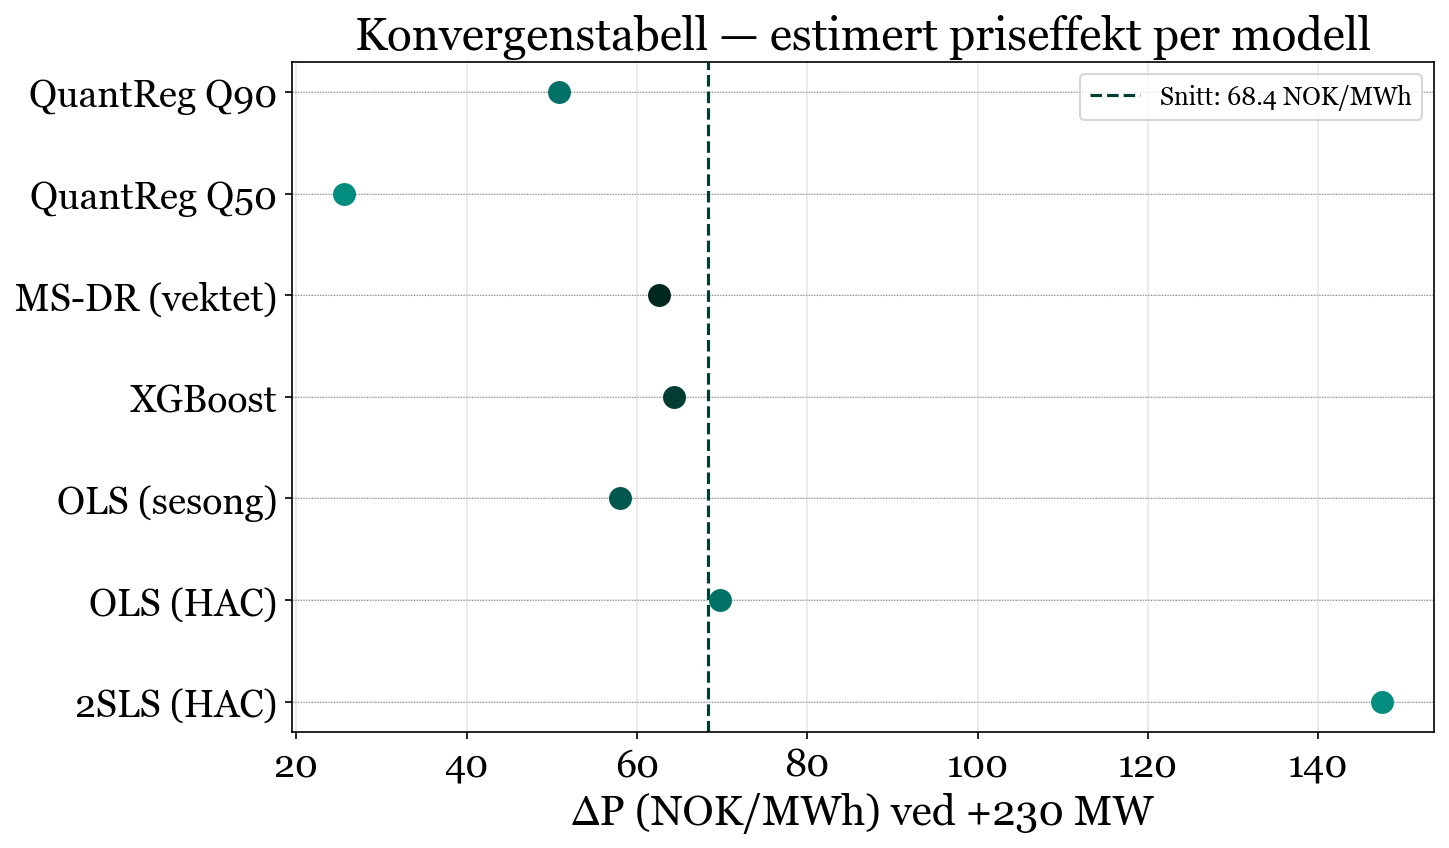

In [24]:
SEC14_DIR = f"{FIG_DIR}05/"
os.makedirs(SEC14_DIR, exist_ok=True)

# OLS-koeffisient (lineær, gir ΔP analytisk)
_bc   = ols_model.params["cons_NO4"]
_se_c = ols_model.bse["cons_NO4"]

_conv_rows = []

# 2SLS (HAC) — hovedmodell, lineær
if tsls_estimator is not None:
    _b_tsls  = tsls_estimator.params["cons_NO4"]
    _se_tsls = tsls_estimator.std_errors["cons_NO4"]
    _conv_rows.append({
        "Modell":          "2SLS (HAC)",
        "ΔP (NOK/MWh)":    round(_b_tsls * STARGATE_MW, 1),
        "KI / spenn":      f"[{(_b_tsls - 1.96*_se_tsls)*STARGATE_MW:.1f}, "
                           f"{(_b_tsls + 1.96*_se_tsls)*STARGATE_MW:.1f}]",
        "Usikkerhetstype": "95 % HAC KI",
    })

# OLS (HAC) — referansemodell, lineær
_conv_rows.append({
    "Modell":          "OLS (HAC)",
    "ΔP (NOK/MWh)":    round(_bc * STARGATE_MW, 1),
    "KI / spenn":      f"[{(_bc - 1.96*_se_c)*STARGATE_MW:.1f}, "
                       f"{(_bc + 1.96*_se_c)*STARGATE_MW:.1f}]",
    "Usikkerhetstype": "95 % HAC KI",
})

# OLS (sesong) — sesongspenn
_conv_rows.append({
    "Modell":          "OLS (sesong)",
    "ΔP (NOK/MWh)":    round(ols_seasonal_sims[STARGATE_MW]["dP"].mean(), 1),
    "KI / spenn":      (
        f"Vinter: {ols_seasonal_sims[STARGATE_MW].loc[ols_seasonal_sims[STARGATE_MW]['season']=='Winter','dP'].mean():.0f} — "
        f"Sommer: {ols_seasonal_sims[STARGATE_MW].loc[ols_seasonal_sims[STARGATE_MW]['season']=='Summer','dP'].mean():.0f}"
    ),
    "Usikkerhetstype": "Sesongspenn",
})

# XGBoost — sesongspenn
_conv_rows.append({
    "Modell":          "XGBoost",
    "ΔP (NOK/MWh)":    round(scenarios[STARGATE_MW]["dP_XGB"].mean(), 1),
    "KI / spenn":      (
        f"Vinter: {scenarios[STARGATE_MW].loc[scenarios[STARGATE_MW]['season']=='Winter','dP_XGB'].mean():.0f} — "
        f"Sommer: {scenarios[STARGATE_MW].loc[scenarios[STARGATE_MW]['season']=='Summer','dP_XGB'].mean():.0f}"
    ),
    "Usikkerhetstype": "Sesongspenn",
})

# MS-DR — vektet 95 % KI
_conv_rows.append({
    "Modell":          "MS-DR (vektet)",
    "ΔP (NOK/MWh)":    round(_dP_w, 1),
    "KI / spenn":      f"[{_dP_w_lo:.1f}, {_dP_w_hi:.1f}]",
    "Usikkerhetstype": "Regime-vektet 95 % KI",
})

# Kvantilregresjon — Q50 (median) og Q90 (øvre hale)
if 0.5 in quantreg_estimators:
    _b_q50  = quantreg_estimators[0.5].params["cons_NO4"]
    _se_q50 = quantreg_estimators[0.5].bse["cons_NO4"]
    _conv_rows.append({
        "Modell":          "QuantReg Q50",
        "ΔP (NOK/MWh)":    round(_b_q50 * STARGATE_MW, 1),
        "KI / spenn":      f"[{(_b_q50 - 1.96*_se_q50)*STARGATE_MW:.1f}, "
                           f"{(_b_q50 + 1.96*_se_q50)*STARGATE_MW:.1f}]",
        "Usikkerhetstype": "95 % KI",
    })
if 0.9 in quantreg_estimators:
    _b_q90  = quantreg_estimators[0.9].params["cons_NO4"]
    _se_q90 = quantreg_estimators[0.9].bse["cons_NO4"]
    _conv_rows.append({
        "Modell":          "QuantReg Q90",
        "ΔP (NOK/MWh)":    round(_b_q90 * STARGATE_MW, 1),
        "KI / spenn":      f"[{(_b_q90 - 1.96*_se_q90)*STARGATE_MW:.1f}, "
                           f"{(_b_q90 + 1.96*_se_q90)*STARGATE_MW:.1f}]",
        "Usikkerhetstype": "95 % KI",
    })

conv_df = pd.DataFrame(_conv_rows).set_index("Modell")
print("Konvergenstabell — Estimert priseffekt av +230 MW Stargate-lastøkning")
print("=" * 70)
display(conv_df)

conv_df.to_csv(f"{INTERMEDIATE_DIR}convergence_table.csv")
print(f"\nLagret: {INTERMEDIATE_DIR}convergence_table.csv")

# Volatilitetstest fra kvantilregresjon
if 0.5 in quantreg_estimators and 0.9 in quantreg_estimators:
    _vol_effect = (_b_q90 - _b_q50) * STARGATE_MW
    print(f"\nVolatilitetseffekt (Q90 − Q50) × {STARGATE_MW} MW: {_vol_effect:+.1f} NOK/MWh")
    print("→ Positivt: Stargate utvider den øvre halen av prisfordelingen mer enn medianen.")

fig, ax = plt.subplots(figsize=(10, 6))
_models_conv  = conv_df.index.tolist()
_dp_vals_conv = conv_df["ΔP (NOK/MWh)"].values.astype(float)

for i, (mod, dp) in enumerate(zip(_models_conv, _dp_vals_conv)):
    ax.scatter(dp, i, s=100, color=PALETTE[i % len(PALETTE)], zorder=5)

for i in range(len(_models_conv)):
    ax.axhline(i, color="grey", lw=0.5, ls=":", zorder=1)

ax.axvline(np.mean(_dp_vals_conv), color=C4, ls="--", lw=1.5,
           label=f"Snitt: {np.mean(_dp_vals_conv):.1f} NOK/MWh")
ax.set_yticks(range(len(_models_conv)))
ax.set_yticklabels(_models_conv)
ax.set_xlabel("ΔP (NOK/MWh) ved +230 MW")
ax.set_title("Konvergenstabell — estimert priseffekt per modell")
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig(f"{SEC14_DIR}convergence_plot.pdf", bbox_inches="tight")
plt.show()


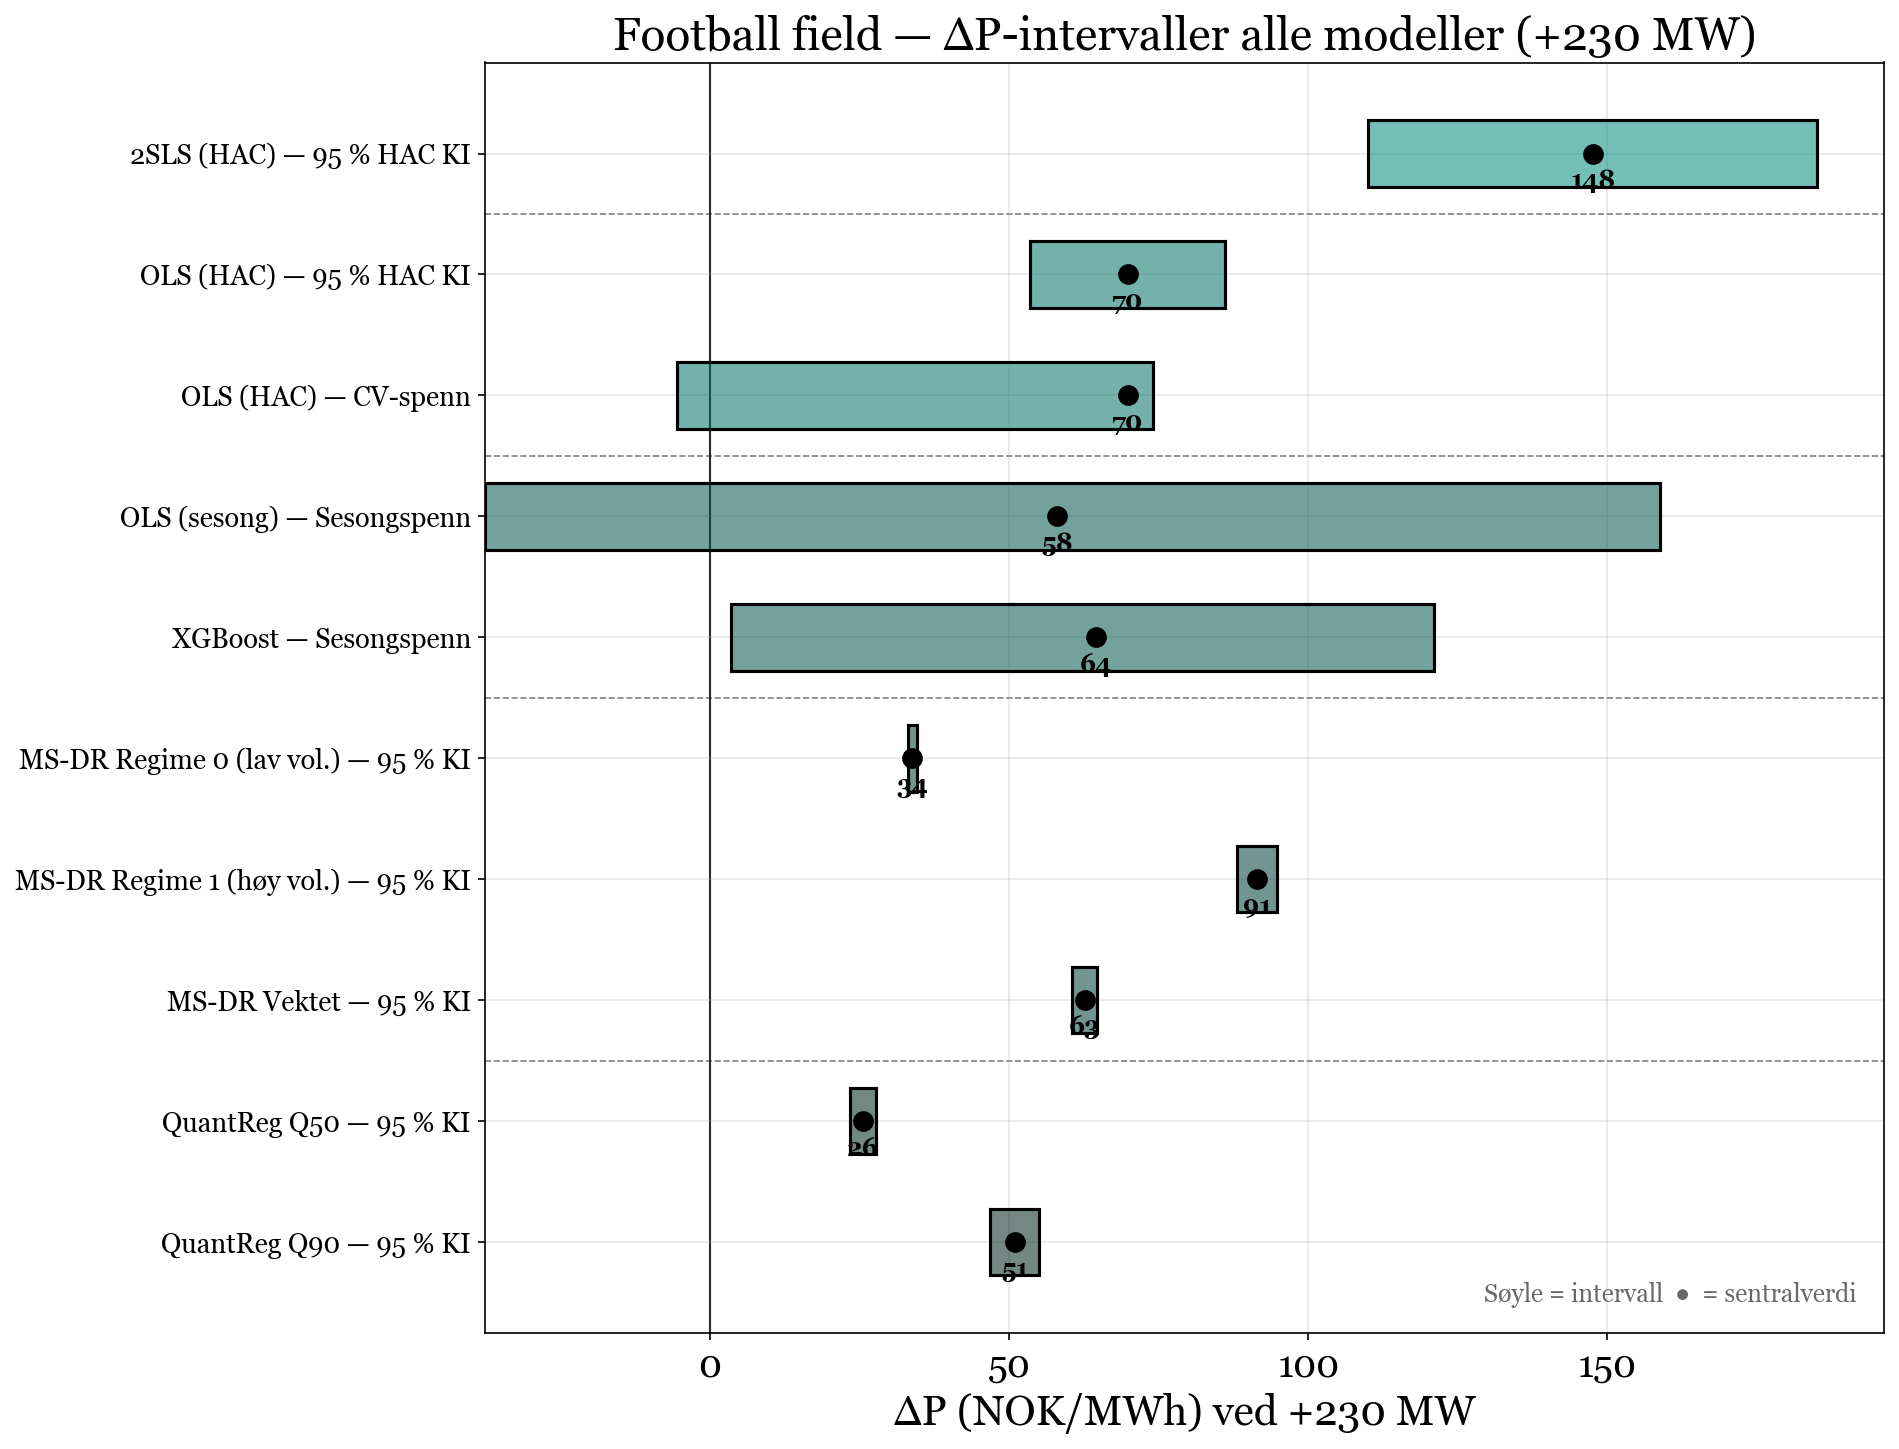

In [25]:
# ── Football field chart — ΔP-intervaller alle modeller ──────────────────────
SEC14_DIR = f"{FIG_DIR}05/"

res230 = scenarios[STARGATE_MW]

# 2SLS (HAC) — 95 % HAC KI
if tsls_estimator is not None:
    _b_tsls  = tsls_estimator.params["cons_NO4"]
    _se_tsls = tsls_estimator.std_errors["cons_NO4"]
    _tsls_dp = _b_tsls * STARGATE_MW
    _tsls_lo = (_b_tsls - 1.96 * _se_tsls) * STARGATE_MW
    _tsls_hi = (_b_tsls + 1.96 * _se_tsls) * STARGATE_MW
else:
    _tsls_dp = _tsls_lo = _tsls_hi = np.nan

# OLS (HAC) — 95 % HAC KI
_ols_dp = _bc * STARGATE_MW
_ols_lo = (_bc - 1.96 * _se_c) * STARGATE_MW
_ols_hi = (_bc + 1.96 * _se_c) * STARGATE_MW

# OLS (HAC) — CV-spenn
_cv_lo = cv_coef_df["cons_NO4"].min() * STARGATE_MW
_cv_hi = cv_coef_df["cons_NO4"].max() * STARGATE_MW

# OLS (sesong) — sesongspenn
_seas_dp_all = {s: res230.loc[res230["season"]==s, "dP_OLS_seasonal"].mean()
                for s in SEASON_ORDER}
_seas_lo = min(_seas_dp_all.values())
_seas_hi = max(_seas_dp_all.values())
_seas_dp = res230["dP_OLS_seasonal"].mean()

# XGBoost — sesongspenn
_xgb_dp_all = {s: res230.loc[res230["season"]==s, "dP_XGB"].mean()
               for s in SEASON_ORDER}
_xgb_lo = min(_xgb_dp_all.values())
_xgb_hi = max(_xgb_dp_all.values())
_xgb_dp = res230["dP_XGB"].mean()

# MS-DR — regime 0, regime 1, vektet KI
_msdr_r0_lo = _ci0[0] * STARGATE_MW
_msdr_r0_hi = _ci0[1] * STARGATE_MW
_msdr_r1_lo = _ci1[0] * STARGATE_MW
_msdr_r1_hi = _ci1[1] * STARGATE_MW

# Kvantilregresjon — Q50 og Q90
if 0.5 in quantreg_estimators:
    _bq50  = quantreg_estimators[0.5].params["cons_NO4"]
    _seq50 = quantreg_estimators[0.5].bse["cons_NO4"]
    _q50_dp = _bq50 * STARGATE_MW
    _q50_lo = (_bq50 - 1.96 * _seq50) * STARGATE_MW
    _q50_hi = (_bq50 + 1.96 * _seq50) * STARGATE_MW
else:
    _q50_dp = _q50_lo = _q50_hi = np.nan

if 0.9 in quantreg_estimators:
    _bq90  = quantreg_estimators[0.9].params["cons_NO4"]
    _seq90 = quantreg_estimators[0.9].bse["cons_NO4"]
    _q90_dp = _bq90 * STARGATE_MW
    _q90_lo = (_bq90 - 1.96 * _seq90) * STARGATE_MW
    _q90_hi = (_bq90 + 1.96 * _seq90) * STARGATE_MW
else:
    _q90_dp = _q90_lo = _q90_hi = np.nan

ROWS = [
    ("2SLS (HAC) — 95 % HAC KI",              _tsls_dp, _tsls_lo,    _tsls_hi,    C1, "HAC KI"),
    ("OLS (HAC) — 95 % HAC KI",               _ols_dp,  _ols_lo,     _ols_hi,     C2, "HAC KI"),
    ("OLS (HAC) — CV-spenn",                  _ols_dp,  _cv_lo,      _cv_hi,      C2, "CV"),
    ("OLS (sesong) — Sesongspenn",            _seas_dp, _seas_lo,    _seas_hi,    C3, "Sesong"),
    ("XGBoost — Sesongspenn",                 _xgb_dp,  _xgb_lo,     _xgb_hi,     C3, "Sesong"),
    ("MS-DR Regime 0 (lav vol.) — 95 % KI",   _dP0,     _msdr_r0_lo, _msdr_r0_hi, C4, "KI"),
    ("MS-DR Regime 1 (høy vol.) — 95 % KI",   _dP1,     _msdr_r1_lo, _msdr_r1_hi, C4, "KI"),
    ("MS-DR Vektet — 95 % KI",                _dP_w,    _dP_w_lo,    _dP_w_hi,    C4, "KI"),
    ("QuantReg Q50 — 95 % KI",                _q50_dp,  _q50_lo,     _q50_hi,     C5, "KI"),
    ("QuantReg Q90 — 95 % KI",                _q90_dp,  _q90_lo,     _q90_hi,     C5, "KI"),
]

# Filtrer ut rader hvor verdier er NaN
ROWS = [r for r in ROWS if not (np.isnan(r[1]) or np.isnan(r[2]) or np.isnan(r[3]))]

labels   = [r[0] for r in ROWS]
centrals = [r[1] for r in ROWS]
los      = [r[2] for r in ROWS]
his      = [r[3] for r in ROWS]
colors   = [r[4] for r in ROWS]

y = np.arange(len(ROWS))
bar_h = 0.55

fig, ax = plt.subplots(figsize=(13, 10))

for i, (lo, hi, c, cent) in enumerate(zip(los, his, colors, centrals)):
    ax.barh(i, hi - lo, left=lo, height=bar_h,
            color=c, alpha=0.55, zorder=2)
    ax.barh(i, hi - lo, left=lo, height=bar_h,
            color=c, alpha=1.0, fill=False, lw=1.5, zorder=3)
    ax.scatter(cent, i, color="black", s=80, zorder=5)
    ax.text(cent, i + bar_h / 2 + 0.06, f"{cent:.0f}",
            ha="center", va="bottom", fontsize=12, fontweight="bold")

# Separasjonslinjer mellom modellgrupper (etter 2SLS, OLS-blokk, sesong-blokk, MS-DR-blokk)
for sep in [0.5, 2.5, 4.5, 7.5]:
    ax.axhline(sep, color="grey", lw=0.8, ls="--", zorder=1)

ax.axvline(0, color="black", lw=1.0, zorder=1)

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=13)
ax.set_xlabel("ΔP (NOK/MWh) ved +230 MW")
ax.set_title(f"Football field — ΔP-intervaller alle modeller (+{STARGATE_MW} MW)")
ax.invert_yaxis()

ax.text(0.98, 0.02,
        "Søyle = intervall  ●  = sentralverdi",
        transform=ax.transAxes, ha="right", va="bottom",
        fontsize=12, color="dimgrey")

plt.tight_layout()
plt.savefig(f"{SEC14_DIR}football_field_dP.pdf", bbox_inches="tight")
plt.show()


In [26]:
# Lagre
with open(INTERMEDIATE_DIR + "scenarios.pkl", "wb") as f:
    pickle.dump({
        "scenarios": scenarios,
        "MODEL_DP": MODEL_DP,
        "iso_share_results": iso_share_results,
        "p90_threshold": p90_threshold,
        "cv_beta_min": cv_coef_df["cons_NO4"].min(),
        "cv_beta_max": cv_coef_df["cons_NO4"].max(),
    }, f)

print("Lagret scenarios.pkl")


Lagret scenarios.pkl
